## Set-Up


In [1]:
!pip install tifffile imaris_ims_file_reader numpy matplotlib opencv-python


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


##### Import Libraries


In [2]:
from datetime import datetime
from skimage import exposure
from tifffile import tifffile
from imaris_ims_file_reader import ims
import matplotlib.pyplot as plt
import numpy as np

## Extracting Images

In [3]:
count = 0 #What number of image set it is
res = 0 # 0 - 5, Not the highest resolution to help segmentation work better
n_slices = 5 #Number of images
thickness = 15

path = "/Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims" #Path to Imaris file

In [ ]:
# Apply gamma correction to the generated images.
def gamma_corr(img, g=1.5):
    return exposure.adjust_gamma(img, g)

def crop(array, threshold=30):
    row_means = array.mean(axis=1)
    col_means = array.mean(axis=0)

    valid_rows = array[row_means >= threshold]
    valid_cols = valid_rows[:, col_means >= threshold]

    return valid_cols

# Save image and do a gamma correction in between as the images are too dark.
def save_cross(array, filename):
    cropped = crop(array, 30)
    
    if cropped.shape[0] <= 50 or cropped.shape[1] <= 50:
        print(f"Skipped Saving Empty Image: {filename}")
        return None
    
    slice_float = cropped.astype(np.float32) # Convert to a float32

    min_val = 0
    max_val = 350
    slice_float = np.clip(slice_float, min_val, max_val)
    
    norm = (slice_float - min_val) / (max_val - min_val)
    
    #corrected = gamma_corr(norm)

    slice_uint16 = (norm * 65535).astype(np.uint16) #Convert to uint16 again

    tifffile.imwrite(filename, slice_uint16, resolution=(300, 300), resolutionunit="inch") # Create image
    print(f"Saved: {filename}")
    
    
def plot_row_col_sums(array, threshold=30, axis = 'yz'):
    row_means = array.mean(axis=1)
    col_means = array.mean(axis=0)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(row_means)
    ax[0].axhline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
    ax[0].set_title(f'Mean intensity per row {axis}')
    ax[0].legend()

    ax[1].plot(col_means)
    ax[1].axhline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
    ax[1].set_title(f"Mean intensity per column {axis}")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

Started at: 16:51:54

Opening readonly file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 


Data shape: (1, 1, 4472, 5997, 7478)

Slice 1 started at: 16:51:54
Slice 1 Shape xy: (5997, 7478)
Saved: NeuN_Af647_3.6x_0_xy_0.tiff
Slice 1 Shape xz: (4472, 7478)
Saved: NeuN_Af647_3.6x_0_xz_0.tiff
Slice 1 Shape yz: (4472, 5997)
Saved: NeuN_Af647_3.6x_0_yz_0.tiff


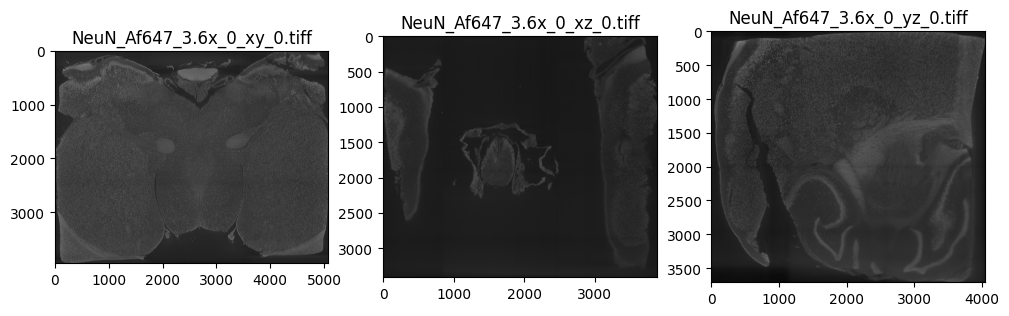

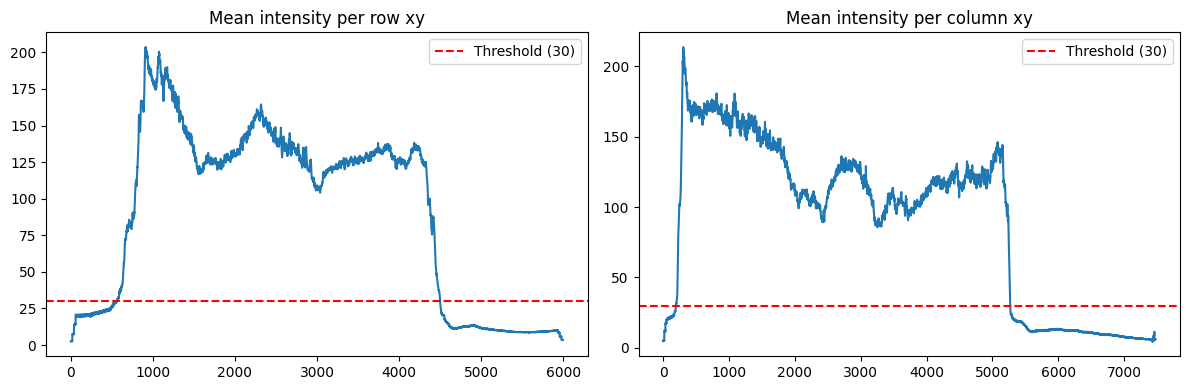

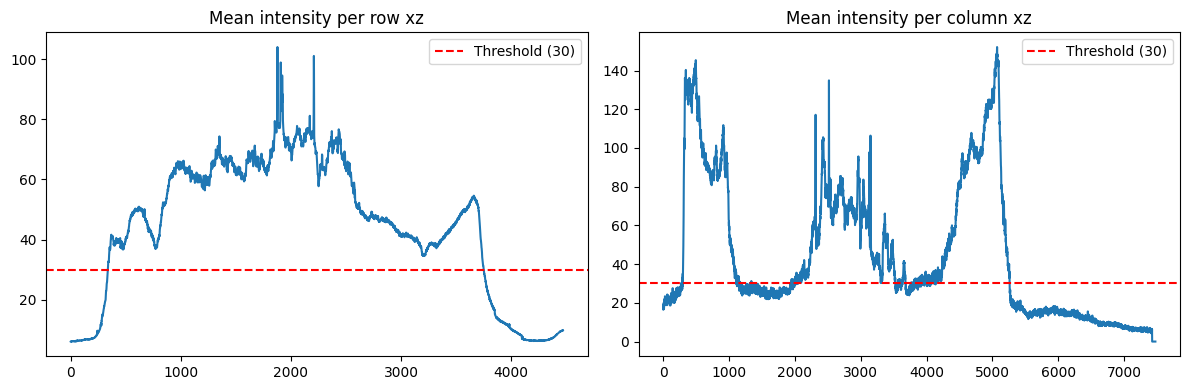

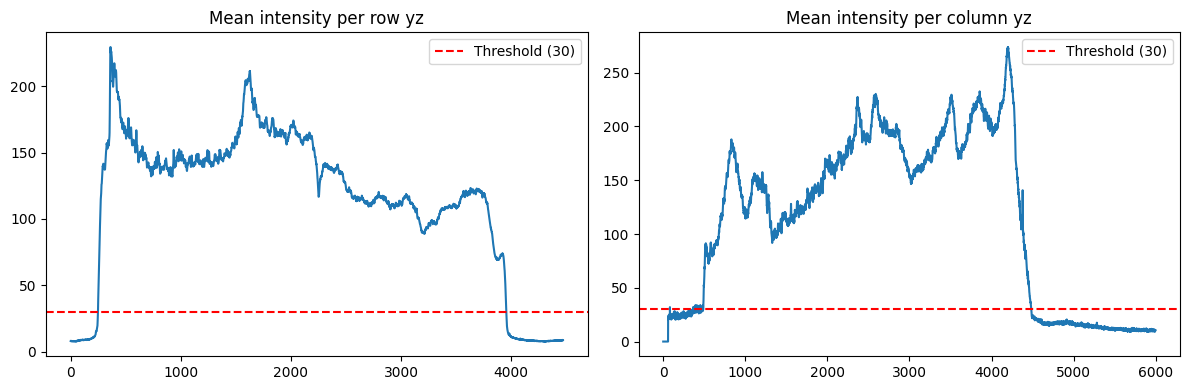

Slice 1 finished at: 16:53:16
Total slice time: 0:01:21.878327


Slice 2 started at: 16:53:16
Slice 2 Shape xy: (5997, 7478)
Saved: NeuN_Af647_3.6x_1_xy_0.tiff
Slice 2 Shape xz: (4472, 7478)
Saved: NeuN_Af647_3.6x_1_xz_0.tiff
Slice 2 Shape yz: (4472, 5997)
Saved: NeuN_Af647_3.6x_1_yz_0.tiff


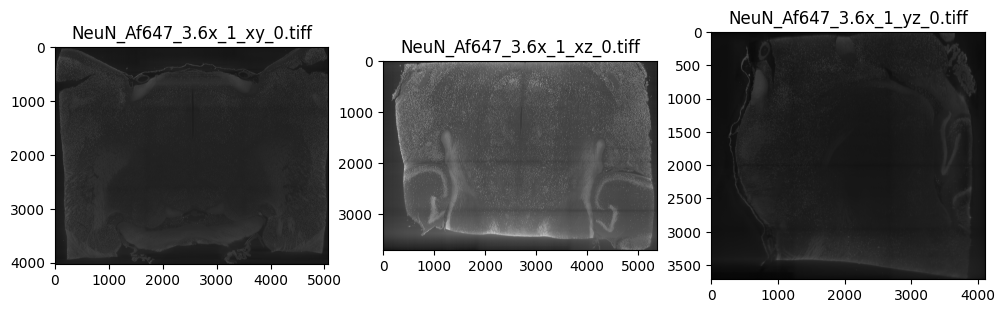

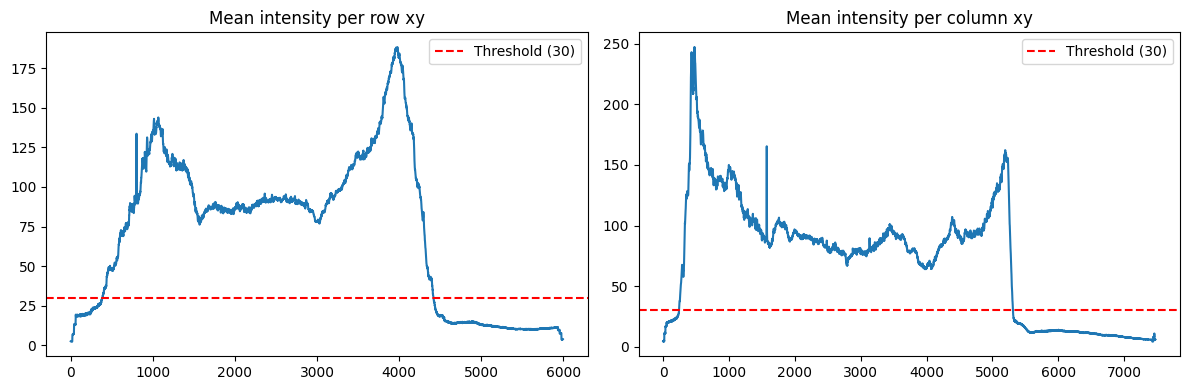

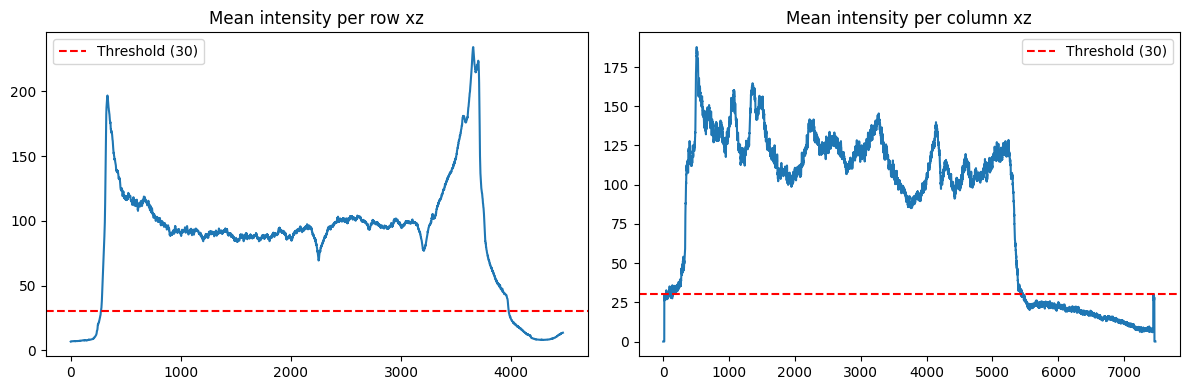

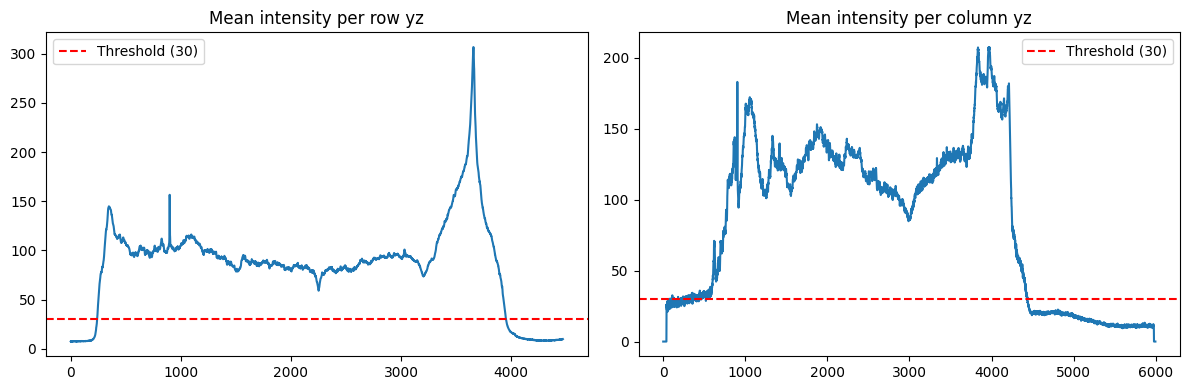

Slice 2 finished at: 16:54:35
Total slice time: 0:01:19.097064


Slice 3 started at: 16:54:35
Slice 3 Shape xy: (5997, 7478)
Saved: NeuN_Af647_3.6x_2_xy_0.tiff
Slice 3 Shape xz: (4472, 7478)
Saved: NeuN_Af647_3.6x_2_xz_0.tiff
Slice 3 Shape yz: (4472, 5997)
Saved: NeuN_Af647_3.6x_2_yz_0.tiff


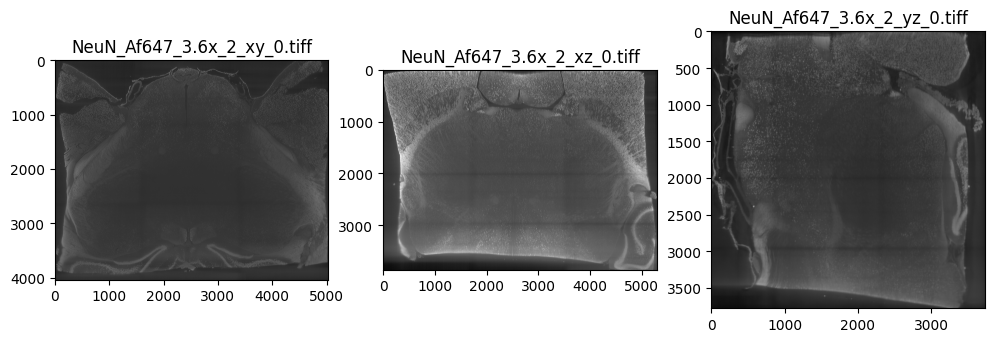

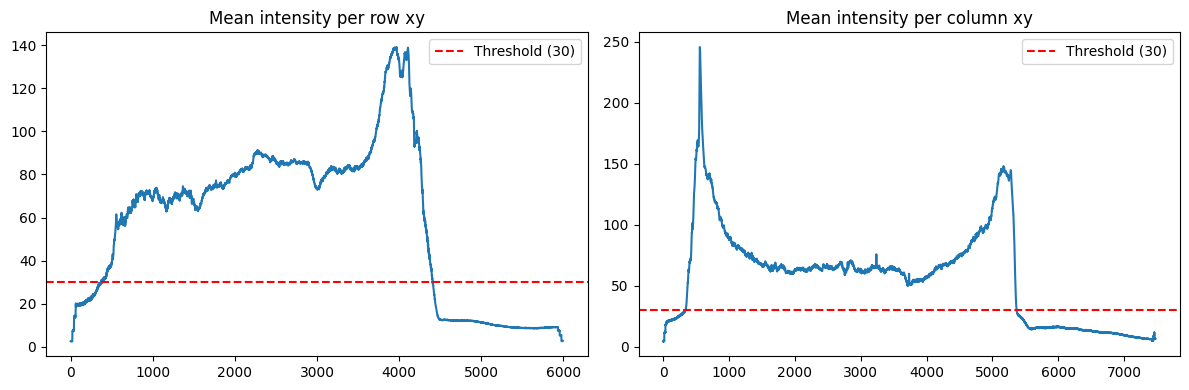

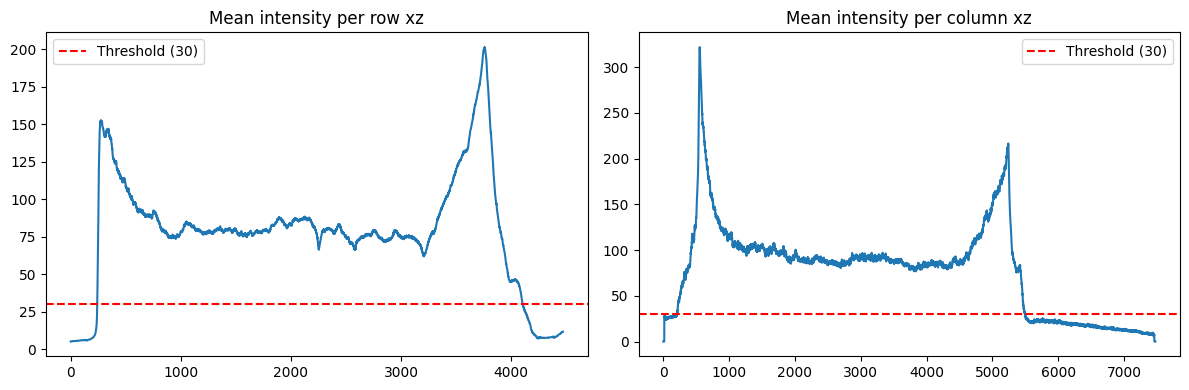

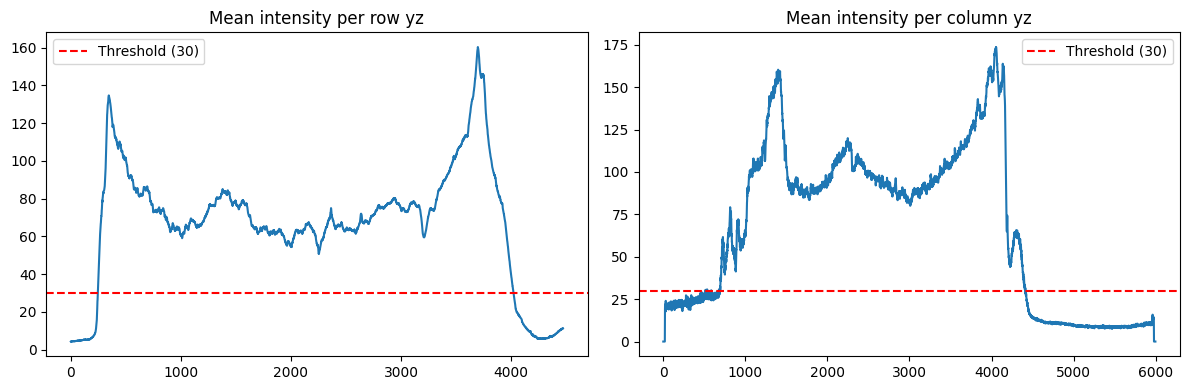

Slice 3 finished at: 16:55:52
Total slice time: 0:01:16.087339


Slice 4 started at: 16:55:52
Slice 4 Shape xy: (5997, 7478)
Saved: NeuN_Af647_3.6x_3_xy_0.tiff
Slice 4 Shape xz: (4472, 7478)
Saved: NeuN_Af647_3.6x_3_xz_0.tiff
Slice 4 Shape yz: (4472, 5997)
Saved: NeuN_Af647_3.6x_3_yz_0.tiff


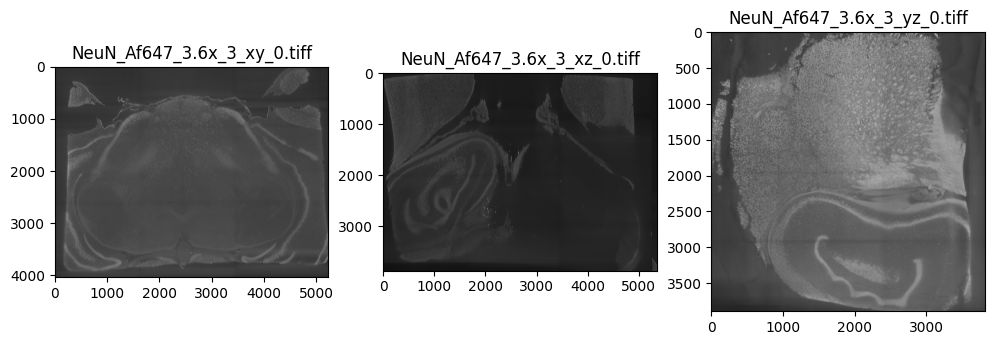

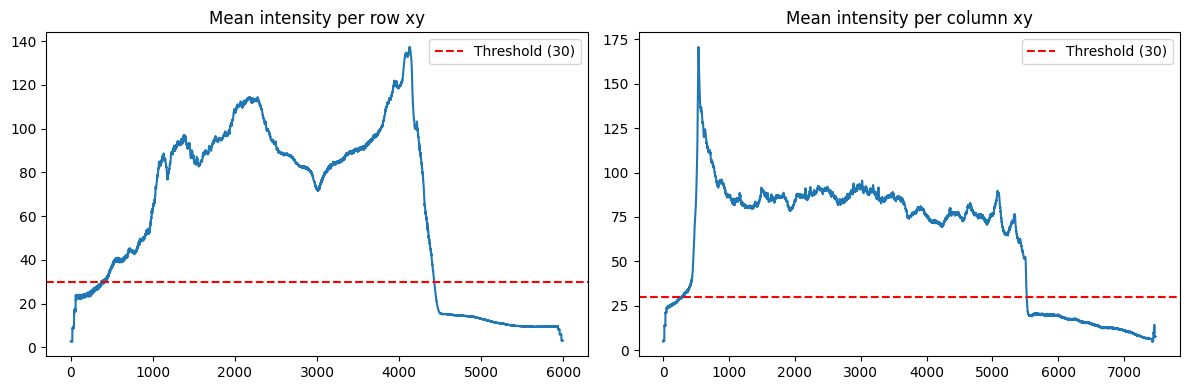

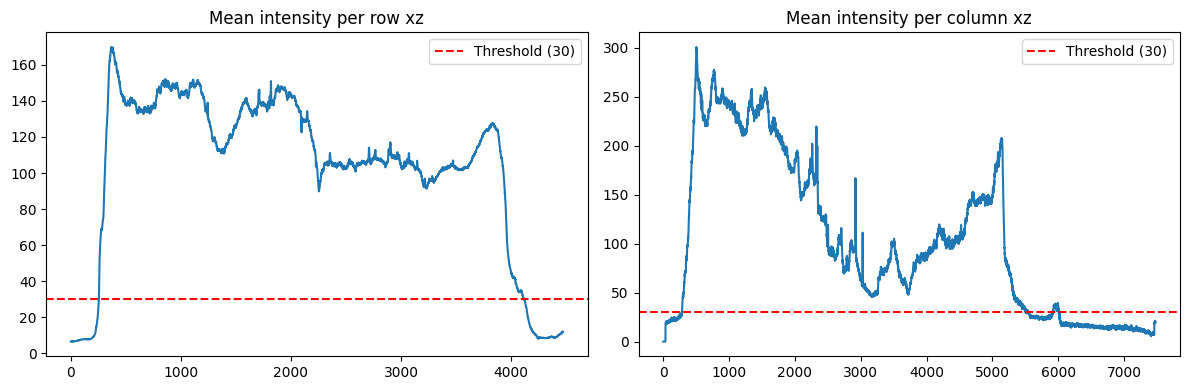

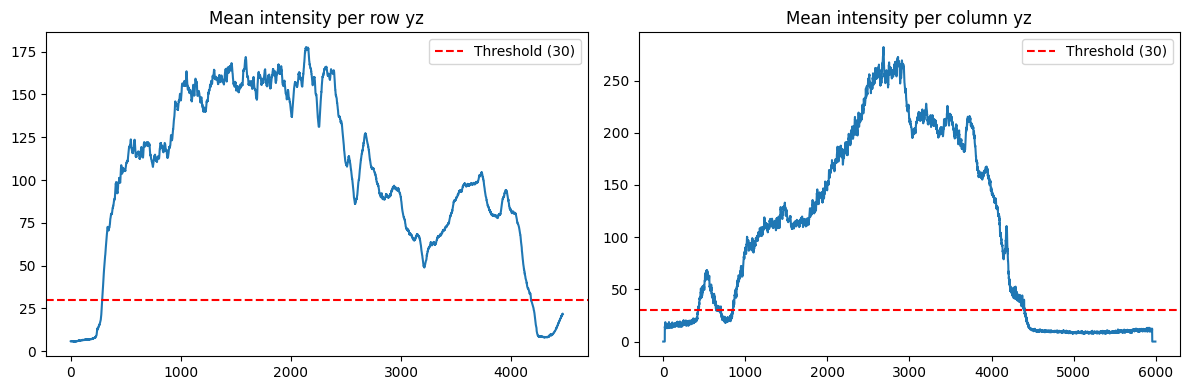

Slice 4 finished at: 16:57:36
Total slice time: 0:01:44.278967


Slice 5 started at: 16:57:36
Slice 5 Shape xy: (5997, 7478)
Saved: NeuN_Af647_3.6x_4_xy_0.tiff
Slice 5 Shape xz: (4472, 7478)
Skipped Saving Empty Image: NeuN_Af647_3.6x_4_xz_0.tiff
Slice 5 Shape yz: (4472, 5997)
Skipped Saving Empty Image: NeuN_Af647_3.6x_4_yz_0.tiff


/var/folders/82/gmlxnfps2yb2zwkc0sj86rxw0000gn/T/ipykernel_4215/192199445.py:42: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[1].imshow(gamma_corr(crop(slice_xz),0.3), cmap='gray')
/var/folders/82/gmlxnfps2yb2zwkc0sj86rxw0000gn/T/ipykernel_4215/192199445.py:42: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax[1].imshow(gamma_corr(crop(slice_xz),0.3), cmap='gray')
/var/folders/82/gmlxnfps2yb2zwkc0sj86rxw0000gn/T/ipykernel_4215/192199445.py:44: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[2].imshow(gamma_corr(crop(slice_yz),0.3), cmap='gray')
/var/folders/82/gmlxnfps2yb2zwkc0sj86rxw0000gn/T/ipykernel_4215/192199445.py:44: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax[2].imshow(gamma_corr(crop(s

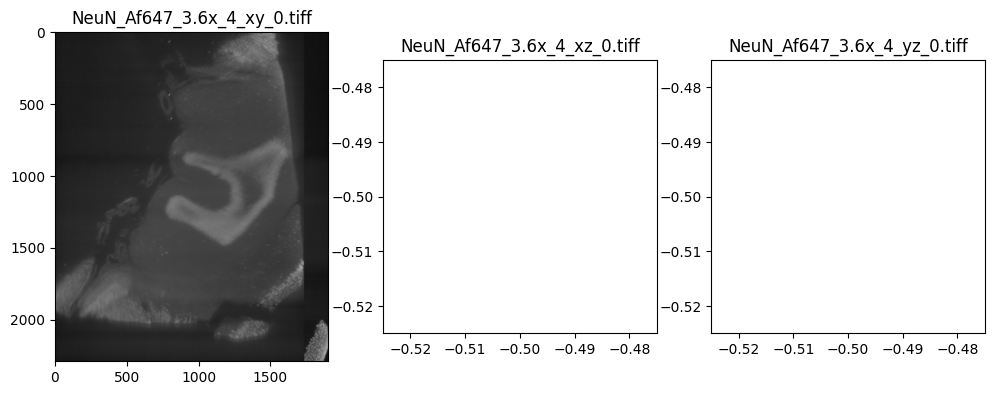

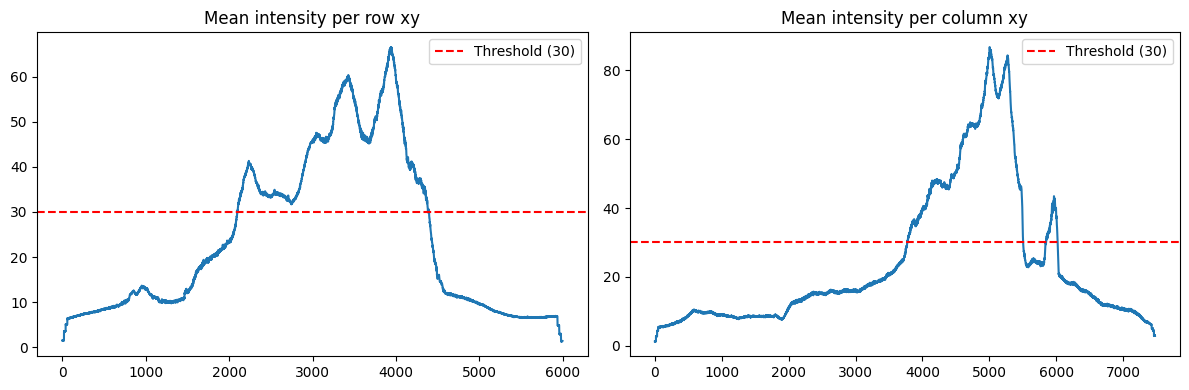

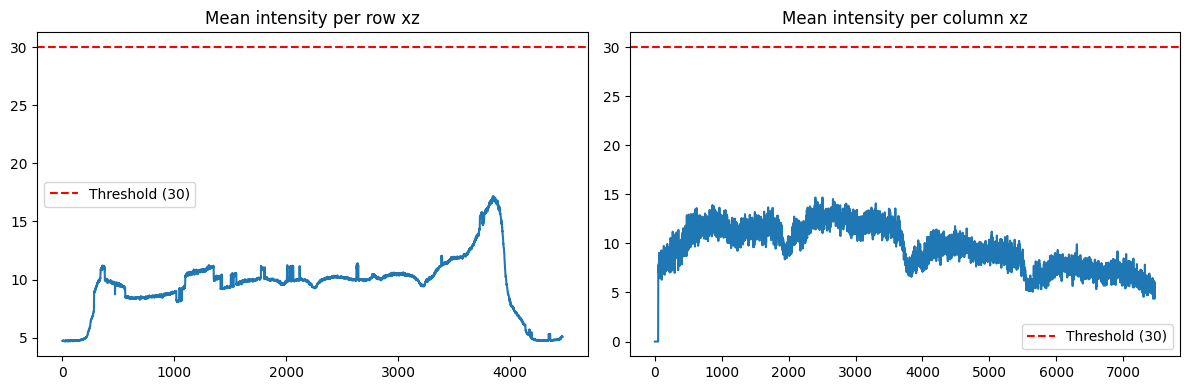

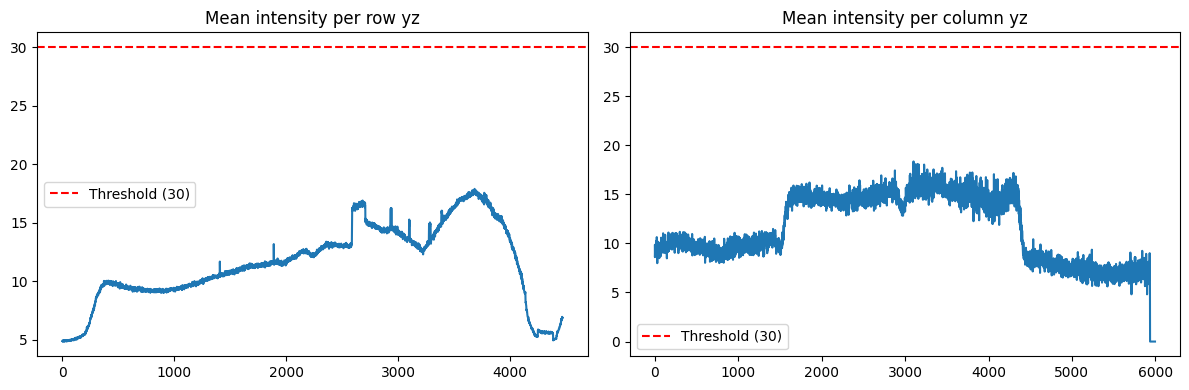

Slice 5 finished at: 16:58:36
Total slice time: 0:00:59.957180


Finished at: 16:58:36
Total time: 0:06:41.352857


In [5]:
start = datetime.now()
print(f"Started at: {start.strftime('%H:%M:%S')}\n")

# ims_data[Time, Channel, z, Y, X]
ims_data = ims(path, ResolutionLevelLock=res)

print(f"\nData shape: {ims_data.shape}")

z_splits = [i * ims_data.shape[2] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes
y_splits = [i * ims_data.shape[3] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes
x_splits = [i * ims_data.shape[4] // n_slices for i in range(n_slices + 1)] # Divide y plane into slices of the same sizes

for i in range(n_slices):
    start_t = datetime.now()
    print(f"\nSlice {(i+1)} started at: {start_t.strftime('%H:%M:%S')}")

    mid_z = (z_splits[i] + z_splits[i+1]) // 2  # midpoint of this slice
    z_end = min(mid_z + thickness, ims_data.shape[2])  # clamp to actual z dimension
    slice_xy = ims_data[0, :, mid_z:z_end, :, :].max(axis=0)  # shape: (C, z, Y, X)
    
    mid_y = (y_splits[i] + y_splits[i+1]) // 2  # midpoint of this slice
    y_end = min(mid_y + thickness, ims_data.shape[3])  # clamp to actual Y dimension
    slice_xz = ims_data[0, :, :, mid_y:y_end, :].max(axis=1)  # shape: (C, z, Y, X)
    
    mid_x = (x_splits[i] + x_splits[i+1]) // 2  # midpoint of this slice
    x_end = min(mid_x + thickness, ims_data.shape[4])  # clamp to actual X dimension
    slice_yz = ims_data[0, :, :, :, mid_x:x_end].max(axis=2)  # shape: (C, z, Y, X)


    print(f"Slice {(i+1)} Shape xy: {slice_xy.shape}")
    save_cross(slice_xy[::-1], f"NeuN_Af647_3.6x_{i}_xy_{count}.tiff") #Create Image
    
    print(f"Slice {(i+1)} Shape xz: {slice_xz.shape}")
    save_cross(slice_xz[::-1], f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff") #Create Image
    
    print(f"Slice {(i+1)} Shape yz: {slice_yz.shape}")
    save_cross(slice_yz[::-1], f"NeuN_Af647_3.6x_{i}_yz_{count}.tiff") #Create Image
    
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(gamma_corr(crop(slice_xy),0.3), cmap='gray')
    ax[0].set_title(f"NeuN_Af647_3.6x_{i}_xy_{count}.tiff")
    ax[1].imshow(gamma_corr(crop(slice_xz),0.3), cmap='gray')
    ax[1].set_title(f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff")
    ax[2].imshow(gamma_corr(crop(slice_yz),0.3), cmap='gray')
    ax[2].set_title(f"NeuN_Af647_3.6x_{i}_yz_{count}.tiff")
    plot_row_col_sums(slice_xy, 30, 'xy')
    plot_row_col_sums(slice_xz, 30, 'xz')
    plot_row_col_sums(slice_yz, 30, 'yz')

    del slice_xy #Delete array from memory
    del slice_xz #Delete array from memory
    del slice_yz #Delete array from memory

    end_t = datetime.now()
    print(f"Slice {(i+1)} finished at: {end_t.strftime('%H:%M:%S')}")
    print(f"Total slice time: {end_t - start_t}\n")

end = datetime.now()
print(f"\nFinished at: {end.strftime('%H:%M:%S')}")
print(f"Total time: {end - start}")

In [ ]:
def oblique_slice(volume, u_vec, v_vec, fill):
    fill_u16 = np.uint16(fill)

    Z, Y, X = volume.shape

    c = np.array([(Z - 1) / 2.0, (Y - 1) / 2.0, (X - 1) / 2.0], dtype=np.float64)

    
    S = int(np.ceil(np.sqrt(Z * Z + Y * Y + X * X)))
    H = W = S

    u = np.asarray(u_vec, dtype=np.float64)
    v = np.asarray(v_vec, dtype=np.float64)

    ii, jj = np.meshgrid(np.arange(H) - H / 2.0, np.arange(W) - W / 2.0, indexing="ij")

    coords = (c[None, None, :] + ii[..., None] * u[None, None, :] + jj[..., None] * v[None, None, :])

    zi = np.rint(coords[..., 0]).astype(np.int64)
    yi = np.rint(coords[..., 1]).astype(np.int64)
    xi = np.rint(coords[..., 2]).astype(np.int64)

    valid = ((zi >= 0) & (zi < Z) &
             (yi >= 0) & (yi < Y) &
             (xi >= 0) & (xi < X))

    zi_c = np.clip(zi, 0, Z - 1)
    yi_c = np.clip(yi, 0, Y - 1)
    xi_c = np.clip(xi, 0, X - 1)

    gathered = volume[zi_c, yi_c, xi_c]

    slice2d = np.where(valid, gathered, fill_u16)

    mask = slice2d > 0

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    slice2d = slice2d[
        rows[0]:rows[-1] + 1,
        cols[0]:cols[-1] + 1
    ]
    
    return slice2d.astype(np.uint16, copy=False)

In [ ]:
def basis_from_euler(alpha_z, beta_y, gamma_x):
    
    ca, sa = np.cos(alpha_z), np.sin(alpha_z)
    cb, sb = np.cos(beta_y),  np.sin(beta_y)
    cg, sg = np.cos(gamma_x), np.sin(gamma_x)

    Rz = np.array([[1, 0,  0], [0, ca,-sa], [0, sa, ca]])
    Ry = np.array([[cb, 0, sb], [ 0, 1,  0], [-sb,0, cb]])
    Rx = np.array([[ cg,-sg, 0], [ sg, cg, 0], [  0,  0, 1]])
    
    R = np.matmul(Rz, np.matmul(Ry, Rx))

    u0 = np.array([0.0, 0.0, 1.0])
    v0 = np.array([0.0, 1.0, 0.0])
    
    u = np.matmul(R, u0)
    v = np.matmul(R, v0)
    
    return u, v

Started at: 03:19:33

Opening readonly file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 

Closing file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 


Data shape: (2236, 2998, 3739)
(3740, 2998) uint16
Slice shape : (2490, 1890)
Slice dtype : uint16
Min / Max   : 0 / 3226
Mean        : 85.23
Nonzero px  : 4705626 / 4706100
Saved: oblique_slice.tiff


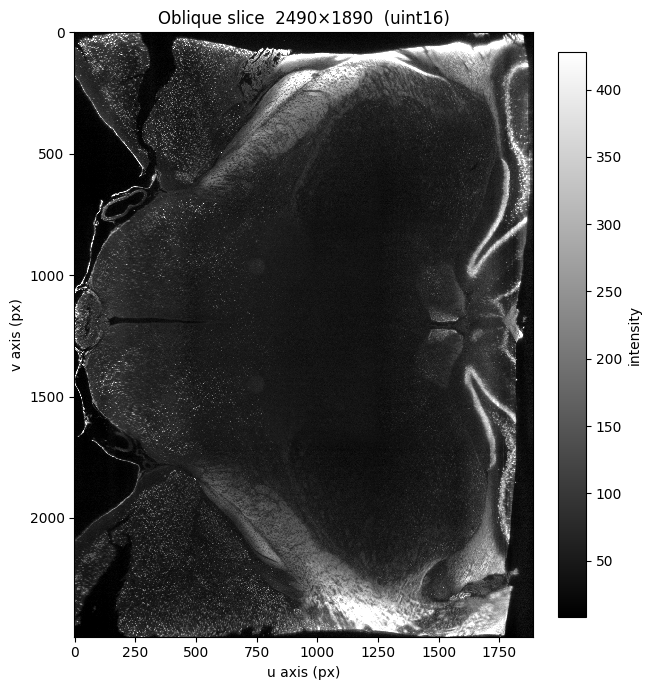


Finished at: 03:22:34
Total time: 0:03:01.589625


In [ ]:
start = datetime.now()
print(f"Started at: {start.strftime('%H:%M:%S')}\n")

vol = ims(path, ResolutionLevelLock=1)[0,0]

print(f"\nData shape: {vol.shape}")

u, v = basis_from_euler(alpha_z=np.deg2rad(0),
                        beta_y=np.deg2rad(0),
                        gamma_x=np.deg2rad(0))

slice2d = oblique_slice(vol, u, v)
print(slice2d.shape, slice2d.dtype)   # e.g. (302, 302) uint16

img = crop(slice2d)

# --- Print quick stats to verify the result
print(f"Slice shape : {img.shape}")
print(f"Slice dtype : {img.dtype}")
print(f"Min / Max   : {img.min()} / {img.max()}")
print(f"Mean        : {img.mean():.2f}")
print(f"Nonzero px  : {np.count_nonzero(img)} / {img.size}")


# --- Save as TIFF
tifffile.imwrite("oblique_slice.tiff", img)
print("Saved: oblique_slice.tiff")

# --- Show the image
# Use percentile-based contrast so a few bright voxels don't wash out the display.
vmin, vmax = np.percentile(img[img > 0], (1, 99)) if np.any(img) else (0, 1)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
ax.set_title(f"Oblique slice  {img.shape[0]}×{img.shape[1]}  (uint16)")
ax.set_xlabel("u axis (px)")
ax.set_ylabel("v axis (px)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="intensity")
plt.tight_layout()
plt.show()

end = datetime.now()
print(f"\nFinished at: {end.strftime('%H:%M:%S')}")
print(f"Total time: {end - start}")

Started at: 03:22:34

Opening readonly file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 

Closing file: /Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims 


Data shape: (1118, 1499, 1869)
(2023, 1447) uint16
Slice shape : (1358, 987)
Slice dtype : uint16
Min / Max   : 0 / 1368
Mean        : 88.87
Nonzero px  : 1324206 / 1340346
Saved: oblique_slice_2.tiff


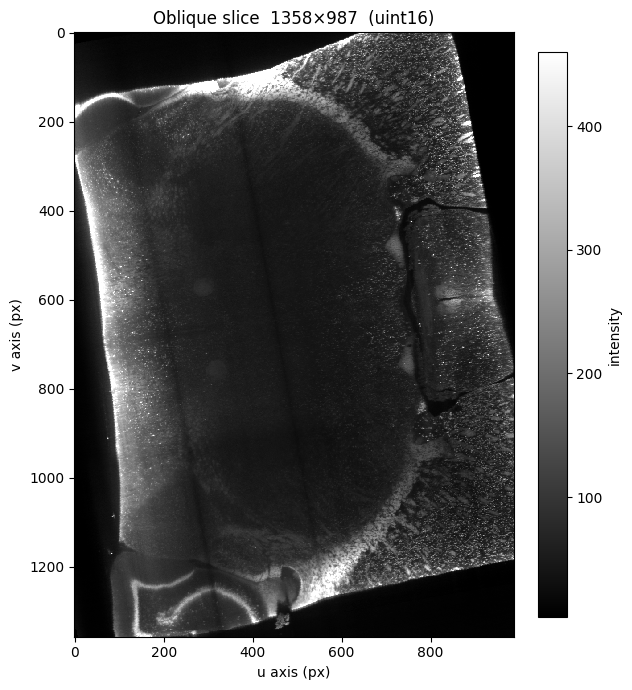


Finished at: 03:22:56
Total time: 0:00:21.400979


In [ ]:
start = datetime.now()
print(f"Started at: {start.strftime('%H:%M:%S')}\n")

vol = ims(path, ResolutionLevelLock=2)[0,0]

print(f"\nData shape: {vol.shape}")

u, v = basis_from_euler(alpha_z=np.deg2rad(0),
                        beta_y=np.deg2rad(10),
                        gamma_x=np.deg2rad(80))

slice2d = oblique_slice(vol, u, v)
print(slice2d.shape, slice2d.dtype)   # e.g. (302, 302) uint16

img = crop(slice2d)

# --- Print quick stats to verify the result
print(f"Slice shape : {img.shape}")
print(f"Slice dtype : {img.dtype}")
print(f"Min / Max   : {img.min()} / {img.max()}")
print(f"Mean        : {img.mean():.2f}")
print(f"Nonzero px  : {np.count_nonzero(img)} / {img.size}")


# --- Save as TIFF
tifffile.imwrite("oblique_slice_2.tiff", img)
print("Saved: oblique_slice_2.tiff")

# --- Show the image
# Use percentile-based contrast so a few bright voxels don't wash out the display.
vmin, vmax = np.percentile(img[img > 0], (1, 99)) if np.any(img) else (0, 1)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
ax.set_title(f"Oblique slice  {img.shape[0]}×{img.shape[1]}  (uint16)")
ax.set_xlabel("u axis (px)")
ax.set_ylabel("v axis (px)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="intensity")
plt.tight_layout()
plt.show()

end = datetime.now()
print(f"\nFinished at: {end.strftime('%H:%M:%S')}")
print(f"Total time: {end - start}")